In [19]:
import requests
import pandas as pd
import re
import time
from bs4 import BeautifulSoup     
import matplotlib.pyplot as plt
import unicodedata
import os
from tqdm import tqdm
import ast

# Drugs FDA API

In [20]:
def load_fda_api_key(path="fda_api_key.txt"):
    """Read the OpenFDA API key from a text file (key after '=')"""
    if not os.path.exists(path):
        print(f"[WARN] API key file '{path}' not found — continuing without key")
        return None

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("fda_api_key_gmail"):
                parts = line.split("=", 1)
                if len(parts) == 2:
                    key = parts[1].strip()
                    if key:
                        print(f"[INFO] Found API key in {path}")
                        return key
    print(f"[WARN] No valid 'fda_api_key=' entry found in {path}")
    return None

API_KEY = load_fda_api_key("fda_api_key.txt")

[INFO] Found API key in fda_api_key.txt


In [21]:
import requests
import re

# manal check of available fields: https://api.fda.gov/drug/label.json?search=openfda.application_number:%22BLA761123%22&limit=1
LABEL_BASE = "https://api.fda.gov/drug/label.json"

def fetch_application_label_details(app_nr):
    params = {
        "search": f'openfda.application_number:"{app_nr}"',
        "limit": 1,
        "sort": "effective_time:desc",
        "api_key": API_KEY
    }
    
    res = requests.get(LABEL_BASE, params=params, timeout=30)
    data = res.json()
    
    if "results" not in data:
        #print("No results found or bad request.")
        return "No results found or bad request.", "No results found or bad request.", "No results found or bad request."
    else:
        result = data["results"][0]
    
        # --- Extract clinical studies text and find all NCT IDs
        clinical_text = " ".join(result.get("clinical_studies", []))
        nct_ids = re.findall(r"NCT\d{8}", clinical_text)
        
        # --- Extract only the first sentence from indications_and_usage
        indications_text = " ".join(result.get("indications_and_usage", []))
        match = re.match(r"^(.*?\.)\s", indications_text)
        first_sentence = match.group(1).strip() if match else indications_text.strip()

        brand_name = " ".join(result.get("brand_name", []))
         
        nct_ids_str = ", ".join(nct_ids) if nct_ids else "No NCTIDs found."

        return nct_ids_str, first_sentence, indications_text


In [4]:
fetch_application_label_details("BLA761123")

('NCT01438489, NCT02446912, NCT02446899',
 '1 INDICATIONS AND USAGE SAPHNELO (anifrolumab-fnia) is indicated for the treatment of adult patients with moderate to severe systemic lupus erythematosus (SLE), who are receiving standard therapy [see Clinical Studies (14) ] .',
 '1 INDICATIONS AND USAGE SAPHNELO (anifrolumab-fnia) is indicated for the treatment of adult patients with moderate to severe systemic lupus erythematosus (SLE), who are receiving standard therapy [see Clinical Studies (14) ] . Limitations of Use The efficacy of SAPHNELO has not been evaluated in patients with severe active lupus nephritis or severe active central nervous system lupus. Use of SAPHNELO is not recommended in these situations. SAPHNELO is a type I interferon (IFN) receptor antagonist indicated for the treatment of adult patients with moderate to severe systemic lupus erythematosus (SLE), who are receiving standard therapy. ( 1 ) Limitations of Use: The efficacy of SAPHNELO has not been evaluated in pati

In [5]:
BASE = "https://api.fda.gov/drug/drugsfda.json"

def _fetch(query, limit=1000):
    out, skip = [], 0
    while True:
        r = requests.get(BASE, params={"search": query, "limit": limit, "skip": skip, "api_key": API_KEY}, timeout=30)
        r.raise_for_status()
        data = r.json()
        out.extend(data.get("results", []))
        if len(data.get("results", [])) < limit:
            break
        skip += limit
    return out

def approvals_in_year(year):
    start, end = f"{year}-01-01", f"{year}-12-31"
    date_range = f"[{start} TO {end}]"

    # All ORIGINAL approvals in the year
    q_all = (
        'submissions.submission_status:"AP" '
        'AND submissions.submission_type:"ORIG" '
        f'AND submissions.submission_status_date:{date_range}'
    )
    results = _fetch(q_all)

    def flatten(recs):
        rows = []
        for r in recs:
            app = r.get("application_number", "")
            sponsor = r.get("sponsor_name")
            # Pull submission rows that match the query year (for the approval date)
            for sub in r.get("submissions", []):
                if sub.get("submission_status") == "AP" and sub.get("submission_type") == "ORIG":
                    sdate = sub.get("submission_status_date")
                    if sdate and sdate[:4] == str(year):
                        scl_desc = sub.get("submission_class_code_description")
                        for prod in r.get("products", []):
                            rows.append({
                                "year": year,
                                "application_number": app,
                                "sponsor": sponsor,
                                "brand_name": prod.get("brand_name"),
                                "route": ", ".join(prod.get("route", []) if isinstance(prod.get("route"), list) else [str(prod.get("route"))]) if prod.get("route") else None,
                                "dosage_form": prod.get("dosage_form"),
                                "active_ingredients": prod.get("active_ingredients"),
                                "submission_status_date": sdate,
                                "submission_class_code_description": scl_desc
                            })
        df = pd.DataFrame(rows)
        # Deduplicate to one row per application (keep earliest approval date in that year)
        if not df.empty:
            df = (df.sort_values(["application_number", "submission_status_date"])
                    .drop_duplicates(subset=["application_number"], keep="first"))
        return df

    df_all = flatten(results)

    if df_all.empty:
        df_novel = df_all.copy()
    else:
        sdesc = df_all["submission_class_code_description"].fillna("")
        keep_mask = sdesc.str.match(r"(?i)^\s*type\s*(1|9)\b")
        df_novel = df_all[keep_mask].copy()
        df_all['is_novel_drug_therapy'] = keep_mask
    
    return df_all.reset_index(drop=True), df_novel.reset_index(drop=True)


In [319]:
# ---- Example
df_all_2021, df_novel_2021 = approvals_in_year(2021)
print("All original approvals:", len(df_all_2021))
print("Novel drug approvals:", len(df_novel_2021))
display(df_novel_2021.head())

All original approvals: 749
Novel drug approvals: 50


,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description
0,2021,BLA761123,ASTRAZENECA AB,SAPHNELO,INJECTION,INJECTABLE,"[{'name': 'ANIFROLUMAB-FNIA', 'strength': '300...",20210730,Type 1 - New Molecular Entity
1,2021,BLA761166,PHARMAESSENTIA CORP,BESREMI,SUBCUTANEOUS,INJECTABLE,"[{'name': 'ROPEGINTERFERON ALFA-2B-NJFT', 'str...",20211112,Type 1 - New Molecular Entity
2,2021,BLA761174,GLAXOSMITHKLINE,JEMPERLI,INJECTION,INJECTABLE,"[{'name': 'DOSTARLIMAB-GXLY', 'strength': '500...",20210422,Type 1 - New Molecular Entity
3,2021,BLA761177,ASCENDIS PHARMA ENCOCRINOLOGY DIV A/S,SKYTROFA,INJECTION,INJECTABLE,"[{'name': 'LONAPEGSOMATROPIN-TCGD', 'strength'...",20210825,Type 1 - New Molecular Entity
4,2021,BLA761178,BIOGEN INC,ADUHELM,INJECTION,INJECTABLE,"[{'name': 'ADUCANUMAB-AVWA', 'strength': '170M...",20210607,Type 1 - New Molecular Entity


In [313]:
df_all_2021.head()

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,indications_and_usage_first_sent,indications_and_usage_full,clinical_trials_nctids,submission_status_date,submission_class_code_description,is_novel_drug_therapy
0,2021,ANDA208660,CHARTWELL RX,LIDOCAINE,TOPICAL,OINTMENT,"[{'name': 'LIDOCAINE', 'strength': '5%'}]",No results found or bad request.,No results found or bad request.,No results found or bad request.,20210105,None,False
1,2021,ANDA214087,SENORES PHARMS,"BUTALBITAL, ACETAMINOPHEN AND CAFFEINE",ORAL,CAPSULE,"[{'name': 'ACETAMINOPHEN', 'strength': '325MG'...","INDICATIONS AND USAGE Butalbital, acetaminophe...","INDICATIONS AND USAGE Butalbital, acetaminophe...",No NCTIDs found.,20210813,None,False


In [259]:
# Containers for all data
all_dfs = []
novel_dfs = []

for year in range(1970, 2025):
    try:
        print(f"fetching data for {year}")
        df_all_year, df_novel_year = approvals_in_year(year)
        
        # Add year column if missing
        if "year" not in df_all_year.columns:
            df_all_year["year"] = year
        if "year" not in df_novel_year.columns:
            df_novel_year["year"] = year
        
        all_dfs.append(df_all_year)
        novel_dfs.append(df_novel_year)
        
        print(f"✅ {year}: {len(df_all_year)} total, {len(df_novel_year)} novel")
    
    except Exception as e:
        print(f"⚠️ Error fetching {year}: {e}")

# Combine all years into final DataFrames
df_all = pd.concat(all_dfs, ignore_index=True)
df_novel = pd.concat(novel_dfs, ignore_index=True)

print("\n--- Summary ---")
print(f"Total approvals collected: {len(df_all):,}")
print(f"Total novel drug approvals: {len(df_novel):,}")

fetching data for 1970
✅ 1970: 48 total, 11 novel
fetching data for 1971
✅ 1971: 95 total, 7 novel
fetching data for 1972
✅ 1972: 147 total, 7 novel
fetching data for 1973
✅ 1973: 179 total, 11 novel
fetching data for 1974
✅ 1974: 238 total, 16 novel
fetching data for 1975
✅ 1975: 158 total, 9 novel
fetching data for 1976
✅ 1976: 256 total, 21 novel
fetching data for 1977
✅ 1977: 234 total, 17 novel
fetching data for 1978
✅ 1978: 244 total, 18 novel
fetching data for 1979
✅ 1979: 170 total, 13 novel
fetching data for 1980
✅ 1980: 184 total, 9 novel
fetching data for 1981
✅ 1981: 265 total, 23 novel
fetching data for 1982
✅ 1982: 323 total, 25 novel
fetching data for 1983
✅ 1983: 249 total, 13 novel
fetching data for 1984
✅ 1984: 316 total, 19 novel
fetching data for 1985
✅ 1985: 373 total, 27 novel
fetching data for 1986
✅ 1986: 443 total, 20 novel
fetching data for 1987
✅ 1987: 450 total, 22 novel
fetching data for 1988
✅ 1988: 418 total, 17 novel
fetching data for 1989
✅ 1989: 235 to

In [314]:
df_all.submission_class_code_description.unique()

array([None, 'Type 5 - New Formulation or New Manufacturer',
       'Type 3 - New Dosage Form', 'Type 1 - New Molecular Entity',
       'Type 2 - New Active Ingredient', 'Type 4 - New Combination',
       'Type 2 New Active Ingredient and Type 4 New Combination',
       'Type 1 - New Molecular Entity and Type 4 - New Combination',
       'Type 6 - New Indication (no longer used)',
       'Type 2 - New Active Ingredient and Type 3 - New Dosage Form',
       'Type 3 - New Dosage Form and Type 4 - New Combination',
       'Not Applicable', 'Type 8 - Partial Rx to OTC Switch',
       'Type 7 - Drug Already Marketed without Approved NDA',
       'Type 9 - New Indication Submitted as Distinct NDA, Consolidated with Original NDA after Approval',
       'Supplement', 'Labeling', 'Efficacy', 'Medical Gas',
       'Type 10 - New Indication Submitted as Distinct NDA - Not Consolidated',
       'Type 9 - New indication submitted as distinct BLA, consolidated',
       'New Combination and New Formu

In [315]:
df_all.head()

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description,is_novel_drug_therapy,active_ingredients_substance
0,1970,ANDA060666,GLAXOSMITHKLINE,TOTACILLIN,ORAL,FOR SUSPENSION,"[{'name': 'AMPICILLIN/AMPICILLIN TRIHYDRATE', ...",19700507,None,False,AMPICILLIN/AMPICILLIN TRIHYDRATE
1,1970,ANDA061187,ALLERGAN,CHLOROPTIC S.O.P.,OPHTHALMIC,OINTMENT,"[{'name': 'CHLORAMPHENICOL', 'strength': '1%'}]",19700721,None,False,CHLORAMPHENICOL
2,1970,ANDA061220,PARKEDALE,OPHTHOCHLOR,OPHTHALMIC,SOLUTION/DROPS,"[{'name': 'CHLORAMPHENICOL', 'strength': '0.5%'}]",19701118,None,False,CHLORAMPHENICOL
3,1970,ANDA080001,ABBOTT,CALCIUM GLUCEPTATE,INJECTION,INJECTABLE,"[{'name': 'CALCIUM GLUCEPTATE', 'strength': 'E...",19700929,None,False,CALCIUM GLUCEPTATE
4,1970,ANDA080016,CHARTWELL MOLECULAR,PROPYLTHIOURACIL,ORAL,TABLET,"[{'name': 'PROPYLTHIOURACIL', 'strength': '50M...",19700724,None,False,PROPYLTHIOURACIL


In [316]:
def extract_active_substances(ingredients):
    """
    Normalize the active_ingredients column:
    - Safely interpret strings like "[{'name': 'X'}]" as Python lists
    - Extract 'name' fields
    - Deduplicate (case-insensitive)
    - Return a semicolon-separated string
    """
    # Step 1: ensure it's a list
    if isinstance(ingredients, str):
        try:
            ingredients = ast.literal_eval(ingredients)
        except (ValueError, SyntaxError):
            ingredients = []
    elif not isinstance(ingredients, list):
        ingredients = []

    # Step 2: extract clean names
    names = []
    for ing in ingredients:
        if isinstance(ing, dict) and "name" in ing:
            name = str(ing["name"]).strip().upper()
            if name:
                names.append(name)

    # Step 3: deduplicate while preserving order
    seen = set()
    unique_names = []
    for name in names:
        if name not in seen:
            seen.add(name)
            unique_names.append(name)

    # Step 4: return semicolon-separated string
    return "; ".join(unique_names) if unique_names else None


# Apply transformation
df_all["active_ingredients_substance"] = df_all["active_ingredients"].apply(extract_active_substances)
df_all.head()

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description,is_novel_drug_therapy,active_ingredients_substance
0,1970,ANDA060666,GLAXOSMITHKLINE,TOTACILLIN,ORAL,FOR SUSPENSION,"[{'name': 'AMPICILLIN/AMPICILLIN TRIHYDRATE', ...",19700507,None,False,AMPICILLIN/AMPICILLIN TRIHYDRATE
1,1970,ANDA061187,ALLERGAN,CHLOROPTIC S.O.P.,OPHTHALMIC,OINTMENT,"[{'name': 'CHLORAMPHENICOL', 'strength': '1%'}]",19700721,None,False,CHLORAMPHENICOL
2,1970,ANDA061220,PARKEDALE,OPHTHOCHLOR,OPHTHALMIC,SOLUTION/DROPS,"[{'name': 'CHLORAMPHENICOL', 'strength': '0.5%'}]",19701118,None,False,CHLORAMPHENICOL
3,1970,ANDA080001,ABBOTT,CALCIUM GLUCEPTATE,INJECTION,INJECTABLE,"[{'name': 'CALCIUM GLUCEPTATE', 'strength': 'E...",19700929,None,False,CALCIUM GLUCEPTATE
4,1970,ANDA080016,CHARTWELL MOLECULAR,PROPYLTHIOURACIL,ORAL,TABLET,"[{'name': 'PROPYLTHIOURACIL', 'strength': '50M...",19700724,None,False,PROPYLTHIOURACIL


In [7]:
df_all = pd.read_csv("out/FDA_all_drug_approvals_1970_2024.csv")
df_all.shape

(23333, 11)

### get indications details from label info

In [8]:
CHECKPOINT_CSV = "out/FDA_label_progress.csv"

# === Load checkpoint if it exists ===
if os.path.exists(CHECKPOINT_CSV):
    df_cache = pd.read_csv(CHECKPOINT_CSV, dtype=str)
    print(f"✅ Loaded checkpoint with {len(df_cache)} saved entries.")
else:
    df_cache = pd.DataFrame(columns=[
        "application_number",
        "clinical_trials_nctids",
        "indications_and_usage_first_sent",
        "indications_and_usage_full"
    ])

# === Merge cache with master list ===
df_all["application_number"] = df_all["application_number"].astype(str)
df_merged = df_all.merge(df_cache, on="application_number", how="left", suffixes=("", "_cached"))

# === Loop with tqdm, skipping completed ===
for i, row in tqdm(df_merged.iterrows(), total=len(df_merged), desc="Fetching FDA labels", unit="app"):
    app_nr = row["application_number"]
    if pd.notna(row.get("indications_and_usage_full")):
        continue  # skip already processed

    nct_ids, first_sent, full_text = fetch_application_label_details(app_nr)
    df_merged.loc[i, "clinical_trials_nctids"] = nct_ids
    df_merged.loc[i, "indications_and_usage_first_sent"] = first_sent
    df_merged.loc[i, "indications_and_usage_full"] = full_text

    # Save progress every 10 rows
    if i % 100 == 0:
        df_merged[[
            "application_number",
            "clinical_trials_nctids",
            "indications_and_usage_first_sent",
            "indications_and_usage_full"
        ]].to_csv(CHECKPOINT_CSV, index=False)


✅ Loaded checkpoint with 23333 saved entries.


Fetching FDA labels: 100%|██████████| 23539/23539 [55:09<00:00,  7.11app/s]  


In [9]:
df_merged.to_csv("out/FDA_all_drug_approvals_1970_2024_indications.csv", index=False)

In [317]:
df_all.shape

(23333, 11)

In [263]:
df_all.to_csv("out/FDA_all_drug_approvals_1970_2024.csv", index=False)

In [264]:
df_novel.submission_class_code_description.unique()

array(['Type 1 - New Molecular Entity',
       'Type 1 - New Molecular Entity and Type 4 - New Combination',
       'Type 9 - New Indication Submitted as Distinct NDA, Consolidated with Original NDA after Approval',
       'Type 9 - New indication submitted as distinct BLA, consolidated'],
      dtype=object)

In [265]:
# Pick the years to compare
years_to_compare = [2011, 2014, 2017, 2020, 2023]

# Filter your dataset
df_compare = df_all[df_all["year"].isin(years_to_compare)].copy()

# Fill NaN submission class with something meaningful
df_compare["submission_class_code_description"] = (
    df_compare["submission_class_code_description"]
    .fillna("Unknown / Not Specified")
    .replace("", "Unknown / Not Specified")
)

# Group and count each submission class description per year
pivot = (
    df_compare
    .groupby(["submission_class_code_description", "year"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Sort by latest year or overall total
pivot = pivot.sort_values(by=years_to_compare[-1], ascending=False)

# Add total row
pivot.loc["Total"] = pivot.sum()

pivot

year,2011,2014,2017,2020,2023
submission_class_code_description,,,,,
Unknown / Not Specified,388,359,821,753,762
Type 1 - New Molecular Entity,27,37,44,52,52
Type 5 - New Formulation or New Manufacturer,20,25,43,23,33
Type 3 - New Dosage Form,21,19,25,22,26
Type 4 - New Combination,7,9,12,6,6
Not Applicable,72,66,20,5,5
Type 2 - New Active Ingredient,0,1,3,4,4
Type 1 - New Molecular Entity and Type 4 - New Combination,2,4,3,2,3
Type 10 - New Indication Submitted as Distinct NDA - Not Consolidated,0,1,1,3,3


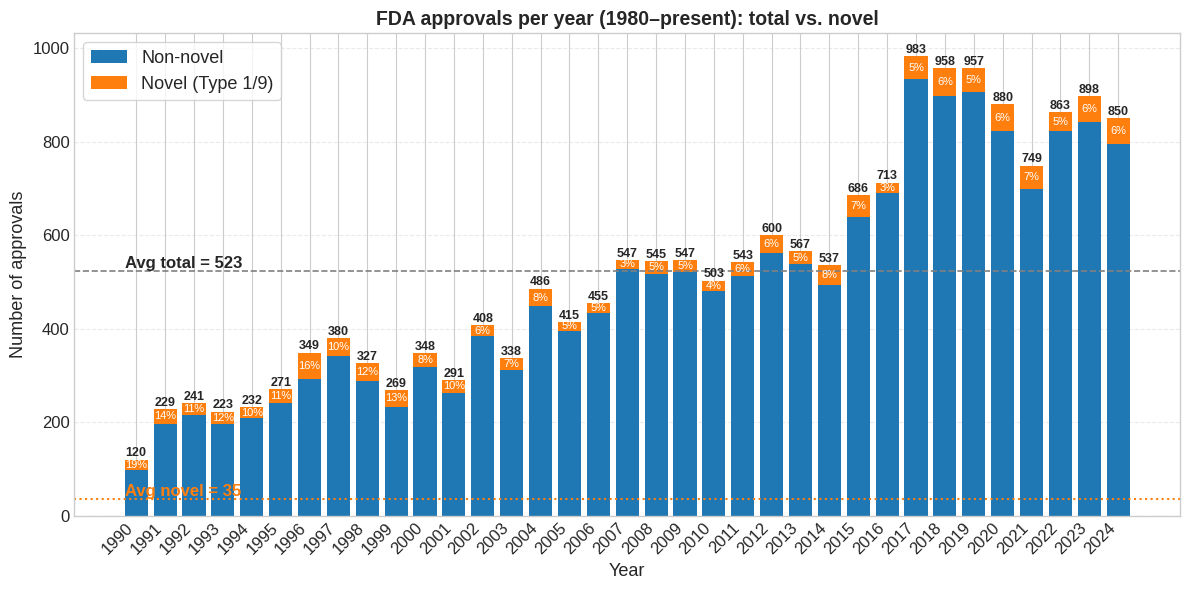

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure dtypes ---
df_all["year"] = pd.to_numeric(df_all["year"], errors="coerce").astype("Int64")
df_all["is_novel_drug_therapy"] = df_all["is_novel_drug_therapy"].fillna(False).astype(bool)

year_filter = 1990
# --- Filter to 1980+ ---
df_1980 = df_all[df_all["year"] >= year_filter].copy()

# --- Aggregate per year ---
yearly = (
    df_1980.groupby("year")
    .agg(total=("application_number", "size"),
         novel=("is_novel_drug_therapy", "sum"))
    .dropna(subset=["total"])
    .sort_index()
)
yearly["non_novel"] = yearly["total"] - yearly["novel"]

# --- Averages over 1980+ period ---
avg_total = yearly["total"].mean()
avg_novel = yearly["novel"].mean()

# --- Prep arrays for plotting (use positional x to avoid dtype issues) ---
years = yearly.index.astype("int64").to_numpy()
x = np.arange(len(years))
total = yearly["total"].to_numpy()
non_novel = yearly["non_novel"].to_numpy()
novel = yearly["novel"].to_numpy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bars
ax.bar(x, non_novel, label="Non-novel")
ax.bar(x, novel, bottom=non_novel, label="Novel (Type 1/9)")

# Total numbers on top of each bar
for xi, tot in zip(x, total):
    ax.text(xi, tot + 0.5, f"{int(tot)}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Novel proportion (%) inside the novel segment
for xi, base, nv, tot in zip(x, non_novel, novel, total):
    if nv > 0 and tot > 0:
        prop = nv / tot
        ax.text(xi, base + nv/2, f"{prop:.0%}", ha="center", va="center", fontsize=8, color="white")

# Average lines (single y-axis)
ax.axhline(avg_total, color="gray", linestyle="--", linewidth=1.2)
ax.text(-0.4, avg_total + 1, f"Avg total = {avg_total:.0f}", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(avg_novel, color="tab:orange", linestyle=":", linewidth=1.5)
ax.text(-0.4, avg_novel + 1, f"Avg novel = {avg_novel:.0f}", va="bottom", color="tab:orange", fontsize=12, fontweight="bold")

# Labels & style
ax.set_title(f"FDA approvals per year ({str(year_filter}–present): total vs. new molecular entities (NMEs)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of approvals", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right")
ax.tick_params(axis="both", labelsize=12)


ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, fontsize=13)

plt.tight_layout()
plt.show()


## validate DB fetched with website data

In [267]:
website_drugs = pd.read_csv("out/FDA_novel_drug_approvals_2011_2024.csv")
website_drugs["drug_name"] = website_drugs["drug_name"].fillna(website_drugs["active_ingredient"])

website_drugs.shape

(603, 7)

In [268]:
df_novel

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description
0,1970,NDA016721,VALEANT PHARM INTL,DALMANE,ORAL,CAPSULE,"[{'name': 'FLURAZEPAM HYDROCHLORIDE', 'strengt...",19700407,Type 1 - New Molecular Entity
1,1970,NDA016750,AMPHASTAR PHARMS INC,CORTROSYN,INJECTION,INJECTABLE,"[{'name': 'COSYNTROPIN', 'strength': '0.25MG/V...",19700422,Type 1 - New Molecular Entity
2,1970,NDA016769,ORTHO MCNEIL JANSSEN,URISPAS,ORAL,TABLET,"[{'name': 'FLAVOXATE HYDROCHLORIDE', 'strength...",19700115,Type 1 - New Molecular Entity
3,1970,NDA016774,NOVARTIS,SERENTIL,ORAL,TABLET,"[{'name': 'MESORIDAZINE BESYLATE', 'strength':...",19700227,Type 1 - New Molecular Entity
4,1970,NDA016782,SOLVAY,LITHONATE,ORAL,CAPSULE,"[{'name': 'LITHIUM CARBONATE', 'strength': '30...",19700406,Type 1 - New Molecular Entity
...,...,...,...,...,...,...,...,...,...
1555,2024,NDA218860,IPSEN,IQIRVO,ORAL,TABLET,"[{'name': 'ELAFIBRANOR', 'strength': '80MG'}]",20240610,Type 1 - New Molecular Entity
1556,2024,NDA218944,SYNDAX,REVUFORJ,ORAL,TABLET,"[{'name': 'REVUMENIB CITRATE', 'strength': 'EQ...",20241115,Type 1 - New Molecular Entity
1557,2024,NDA219008,JANSSEN BIOTECH,LAZCLUZE,ORAL,TABLET,"[{'name': 'LAZERTINIB MESYLATE', 'strength': '...",20240819,Type 1 - New Molecular Entity
1558,2024,NDA219132,INTRABIO,AQNEURSA,ORAL,FOR SUSPENSION,"[{'name': 'LEVACETYLLEUCINE', 'strength': '1GM...",20240924,Type 1 - New Molecular Entity


In [270]:
import re

def partial_match(name, drug_list):
    if pd.isna(name):
        return None
    name_upper = str(name).upper().strip()
    for drug in drug_list:
        # stricter: match whole token (word boundary), escape special chars
        pat = r'\b' + re.escape(drug) + r'\b'
        if re.search(pat, name_upper):
            return drug
    return None

for year in range(2011, 2025):
    print(f"\nchecking year {year}")
    target_drugs_list = list(website_drugs[website_drugs['year'] == year].drug_name)
    # unique, clean targets
    drug_names_upper = sorted({str(d).upper().strip() for d in target_drugs_list if pd.notna(d)})
    print(f"target drugs {len(drug_names_upper)}")

    df_novel["year"] = pd.to_numeric(df_novel["year"], errors="coerce").astype("Int64")
    df_novel_year = df_novel.loc[df_novel["year"] == year].copy()
    print(f"FDA novel drugs {df_novel_year.shape}")

    # compute matches once
    df_novel_year.loc[:, "brand_norm"] = df_novel_year["brand_name"].astype(str).str.upper().str.strip()
    df_novel_year.loc[:, "matched_drug"] = df_novel_year["brand_norm"].apply(
        lambda x: partial_match(x, drug_names_upper)
    )
    df_matched = df_novel_year.dropna(subset=["matched_drug"])

    print(f"{df_matched['matched_drug'].nunique()} of {len(drug_names_upper)} drugs matched")

    # reference vs found (by canonical target names)
    set_ref = set(drug_names_upper)
    set_found = set(df_matched["matched_drug"].str.upper())
    missing_drugs = sorted(set_ref - set_found)
    print(f"Drugs missing from dataset ({len(missing_drugs)}):")
    for d in missing_drugs:
        print(" -", d)

    # extras = rows that did NOT match any target by partial_match
    df_extras = df_novel_year[df_novel_year["matched_drug"].isna()].copy()
    extra_brands = (
        df_extras.groupby("brand_norm")["submission_class_code_description"]
        .size()
        .reset_index(name="rows")
        .sort_values(["rows", "brand_norm"], ascending=[False, True])
    )

    print(
        f"Extras in FDA dataset not in website list: "
        f"{len(df_extras)} unmatched rows across {len(extra_brands)} unique brands"
    )
    for _, r in extra_brands.iterrows():
        subcls = (
            df_extras.loc[df_extras["brand_norm"] == r["brand_norm"], "submission_class_code_description"]
            .dropna().unique()
        )
        subcls_str = "; ".join(sorted(map(str, subcls))) if len(subcls) else "NA"
        print(f" - {r['brand_norm']}  (rows={r['rows']})  {subcls_str}")



checking year 2011
target drugs 30
FDA novel drugs (31, 9)
29 of 30 drugs matched
Drugs missing from dataset (1):
 - ERWINAZE
Extras in FDA dataset not in website list: 1 unmatched rows across 1 unique brands
 - ZYCLARA  (rows=1)  Type 9 - New Indication Submitted as Distinct NDA, Consolidated with Original NDA after Approval

checking year 2012
target drugs 39
FDA novel drugs (38, 9)
35 of 39 drugs matched
Drugs missing from dataset (4):
 - BELVIQ
 - CHOLINE C 11 INJECTION
 - FULYZAQ
 - NEUTROVAL
Extras in FDA dataset not in website list: 3 unmatched rows across 3 unique brands
 - CHOLINE C-11  (rows=1)  Type 1 - New Molecular Entity
 - GRANIX  (rows=1)  Type 1 - New Molecular Entity
 - MYTESI  (rows=1)  Type 1 - New Molecular Entity

checking year 2013
target drugs 27
FDA novel drugs (29, 9)
26 of 27 drugs matched
Drugs missing from dataset (1):
 - BRINTELLIX
Extras in FDA dataset not in website list: 3 unmatched rows across 3 unique brands
 - STIVARGA  (rows=1)  Type 9 - New Indica

## check results

In [13]:
df_1970_2024_indications = pd.read_csv("./out/FDA_all_drug_approvals_1970_2024_indications.csv")

In [18]:
df_1970_2024_indications[df_1970_2024_indications["active_ingredients_substance"]=="CLADRIBINE"]

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description,is_novel_drug_therapy,active_ingredients_substance,clinical_trials_nctids,indications_and_usage_first_sent,indications_and_usage_full
5818,1993,NDA020229,JANSSEN PHARMS,LEUSTATIN,INJECTION,INJECTABLE,"[{'name': 'CLADRIBINE', 'strength': '1MG/ML **...",19930226,Type 1 - New Molecular Entity,True,CLADRIBINE,No results found or bad request.,No results found or bad request.,No results found or bad request.
7803,2000,ANDA075405,HIKMA,CLADRIBINE,INJECTION,INJECTABLE,"[{'name': 'CLADRIBINE', 'strength': '1MG/ML'}]",20000228,NaN,False,CLADRIBINE,No NCTIDs found.,"INDICATIONS AND USAGE Cladribine Injection, US...","INDICATIONS AND USAGE Cladribine Injection, US..."
9275,2004,ANDA076571,FRESENIUS KABI USA,CLADRIBINE,INJECTION,INJECTABLE,"[{'name': 'CLADRIBINE', 'strength': '1MG/ML'}]",20040422,NaN,False,CLADRIBINE,No NCTIDs found.,"INDICATIONS AND USAGE: Cladribine Injection, U...","INDICATIONS AND USAGE: Cladribine Injection, U..."
12971,2011,ANDA200510,PHARMOBEDIENT,CLADRIBINE,INJECTION,INJECTABLE,"[{'name': 'CLADRIBINE', 'strength': '1MG/ML'}]",20111006,Not Applicable,False,CLADRIBINE,No results found or bad request.,No results found or bad request.,No results found or bad request.
18812,2019,ANDA210856,HISUN PHARM HANGZHOU,CLADRIBINE,INJECTION,INJECTABLE,"[{'name': 'CLADRIBINE', 'strength': '1MG/ML'}]",20191125,NaN,False,CLADRIBINE,No results found or bad request.,No results found or bad request.,No results found or bad request.
19125,2019,NDA022561,EMD SERONO INC,MAVENCLAD,ORAL,TABLET,"[{'name': 'CLADRIBINE', 'strength': '10MG'}]",20190329,Type 3 - New Dosage Form,False,CLADRIBINE,No results found or bad request.,No results found or bad request.,No results found or bad request.


In [26]:
tqdm.pandas()

df = df_1970_2024_indications.copy()

# Create mask for rows that meet both conditions
mask = (
    df["application_number"].astype(str).str.startswith("NDA")
    & (df["indications_and_usage_first_sent"] == "No results found or bad request.")
)

# Iterate through matching rows with progress bar
for idx in tqdm(df[mask].index, desc="Updating NDA rows", unit="row"):
    app_no = df.at[idx, "application_number"]
    try:
        details = fetch_application_label_details(app_no)
        if details and isinstance(details, dict):
            df.at[idx, "clinical_trials_nctids"] = details.get("clinical_trials_nctids", "")
            df.at[idx, "indications_and_usage_first_sent"] = details.get("indications_and_usage_first_sent", "")
            df.at[idx, "indications_and_usage_full"] = details.get("indications_and_usage_full", "")
    except Exception as e:
        print(f"⚠️ Error updating {app_no}: {e}")

Updating NDA rows: 100%|██████████| 2163/2163 [28:24<00:00,  1.27row/s] 


In [24]:
filtered = df[
    df['application_number'].str.startswith('NDA', na=False) &
    (df['indications_and_usage_first_sent'] == 'No results found or bad request.')
]
filtered

,year,application_number,sponsor,brand_name,route,dosage_form,active_ingredients,submission_status_date,submission_class_code_description,is_novel_drug_therapy,active_ingredients_substance,clinical_trials_nctids,indications_and_usage_first_sent,indications_and_usage_full
10,1970,NDA015419,BRACCO,HIPPUTOPE,INJECTION,INJECTABLE,"[{'name': 'IODOHIPPURATE SODIUM I-131', 'stren...",19700625,Type 5 - New Formulation or New Manufacturer,False,IODOHIPPURATE SODIUM I-131,No results found or bad request.,No results found or bad request.,No results found or bad request.
11,1970,NDA016118,BRISTOL MYERS SQUIBB,TESLAC,ORAL,TABLET,"[{'name': 'TESTOLACTONE', 'strength': '250MG'}]",19700527,Type 3 - New Dosage Form,False,TESTOLACTONE,No results found or bad request.,No results found or bad request.,No results found or bad request.
16,1970,NDA016721,VALEANT PHARM INTL,DALMANE,ORAL,CAPSULE,"[{'name': 'FLURAZEPAM HYDROCHLORIDE', 'strengt...",19700407,Type 1 - New Molecular Entity,True,FLURAZEPAM HYDROCHLORIDE,No results found or bad request.,No results found or bad request.,No results found or bad request.
20,1970,NDA016758,PFIZER,NAVANE,ORAL,CONCENTRATE,"[{'name': 'THIOTHIXENE HYDROCHLORIDE', 'streng...",19700406,Type 2 - New Active Ingredient,False,THIOTHIXENE HYDROCHLORIDE,No results found or bad request.,No results found or bad request.,No results found or bad request.
21,1970,NDA016765,ELORAC,FLUOROPLEX,TOPICAL,SOLUTION,"[{'name': 'FLUOROURACIL', 'strength': '1%'}]",19700731,Type 3 - New Dosage Form,False,FLUOROURACIL,No results found or bad request.,No results found or bad request.,No results found or bad request.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23517,2024,NDA218710,PHATHOM PHARMACEUTICALS INC,VOQUEZNA,ORAL,TABLET,"[{'name': 'VONOPRAZAN FUMARATE', 'strength': '...",20240717,Type 9 - New Indication Submitted as Distinct ...,True,VONOPRAZAN FUMARATE,No results found or bad request.,No results found or bad request.,No results found or bad request.
23521,2024,NDA218771,ALMAJECT,TERIPARATIDE,SUBCUTANEOUS,SOLUTION,"[{'name': 'TERIPARATIDE', 'strength': '0.56MG/...",20240604,Type 5 - New Formulation or New Manufacturer,False,TERIPARATIDE,No results found or bad request.,No results found or bad request.,No results found or bad request.
23536,2024,NDA219709,WSM SUPPLIER LLC,"MEDICAL AIR, USP",INHALATION,GAS,"[{'name': 'MEDICAL AIR', 'strength': 'N/A'}]",20240713,NaN,False,MEDICAL AIR,No results found or bad request.,No results found or bad request.,No results found or bad request.
23537,2024,NDA219779,CENTRAL WELDING SUPPLY,"CARBON DIOXIDE, USP",INHALATION,GAS,"[{'name': 'CARBON DIOXIDE', 'strength': 'N/A'}]",20240810,NaN,False,CARBON DIOXIDE,No results found or bad request.,No results found or bad request.,No results found or bad request.
